In [ ]:
# Filtered Data
DATA_DIR = '/singleCell/Kamath2022_DAneuron/snRNA-seq/'
# Homo sapiens '62734a9e771a5b02c437a7da/'
# Macaca fascicularis '627331b0771a5b02c437a6d0/'
# Tupaia '627331b0771a5b02c437a6d2/'
# Rattus '627331b0771a5b02c437a6d1/'

library(dplyr)
library(Seurat)
library(patchwork)


## Default Seurat Processing 
# Data previously filtered 
obj <- Read10X(data.dir = paste0(DATA_DIR,'raw_hs/'))
obj <- CreateSeuratObject(counts = obj, min.cells = 3, min.features = 200) 

# --------------------------------------------------------------------------------
## Add Metadata
metadata = read.table(paste0(DATA_DIR,'raw_hs/METADATA_PD.tsv.gz'),row.names = 1, header=T) 
metadata = metadata[-1,]
metadata$Id = rownames(metadata)
# DA Annotations 
DA_anno = read.table(paste0(DATA_DIR,'SCP1768/cluster/da_UMAP.tsv'),row.names = 1, header=T)
DA_anno = DA_anno[-1,]
DA_anno$Id = rownames(DA_anno)
metadata = left_join(DA_anno,metadata, by='Id')
rownames(metadata) = metadata$Id
# obj metadata
obj <- subset(obj, cells = rownames(metadata))
obj@meta.data$Id <- rownames(obj@meta.data)
metadata1 <- obj@meta.data[,'Id',drop=F]
metadata1 <- left_join(metadata1, metadata, by='Id')
obj <- AddMetaData(obj, metadata1)
obj@meta.data

table(obj@meta.data$Status)
table(obj@meta.data$Donor_Age)
table(obj@meta.data$Cell_Type)
# --------------------------------------------------------------------------------
## Default Seurat Processing 
obj <- NormalizeData(obj, verbose = F) %>%
FindVariableFeatures(verbose = F) %>%
ScaleData(verbose = F) %>%
RunPCA(verbose = F) %>%
FindNeighbors(verbose = F) %>%
FindClusters(algorithm = 2, resolution = 0.5, verbose = F) %>%
RunUMAP(dims = 1:10, verbose = F)
DimPlot(obj, group.by='Cell_Type')
saveRDS(obj,paste0(DATA_DIR,'processed/Kamath2022_DAneuron_snRNA_hs_processed.rds'))
# --------------------------------------------------------------------------------

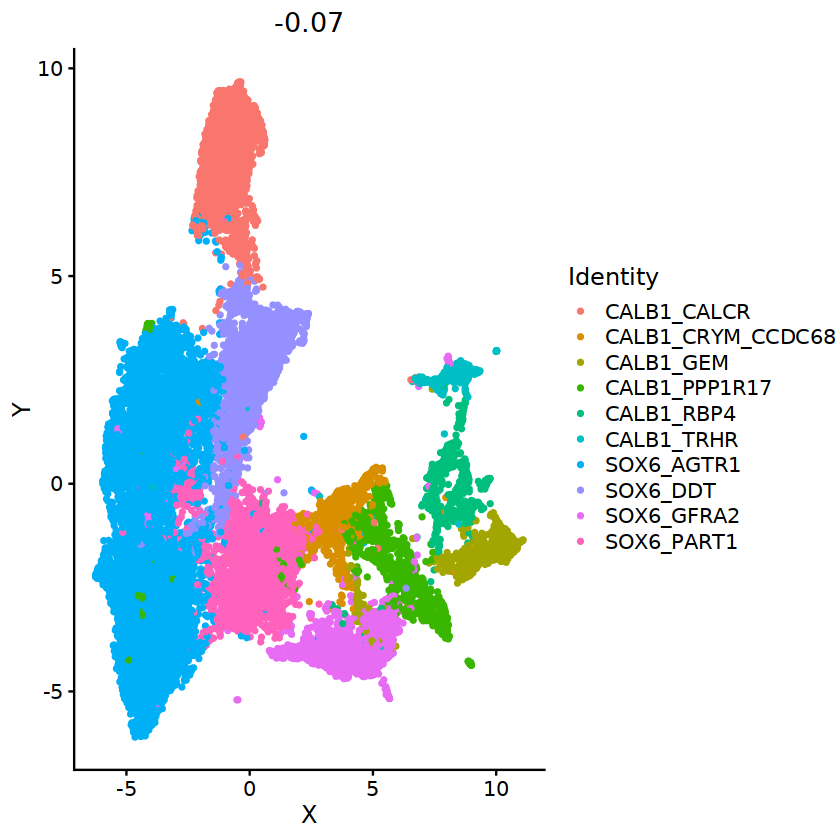

In [30]:
# DA UMAP (based on paper's analysis)
obj@meta.data[,c('X','Y')] <- lapply(obj@meta.data[,c('X','Y')], as.numeric)
FeatureScatter(obj, feature1 = "X", feature2 = "Y", group.by='Cell_Type')